In [3]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np


import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/nadavmi/backup')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
#from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick


# This function receives a dataframe, coordinates columns, source assembly and target assembly. It lifts over the coords and adds lifted coords to the df.
# assuming coords are 1-based.
os.chdir('/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI')
from liftOver import initializer as initializer
from liftOver import liftOver_df as liftOver

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


# Phase 1: cCRE ATAC-seq Signal Analysis - SCREEN Data
## ATAC-seq Specificity Across Cell Types

Intersect in_vitro_differentiated SCREEN cCREs with ATAC-seq bedGraph data and visualize ATAC-seq signal value distributions across cell types.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import pybedtools
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Suppress pybedtools warnings
pybedtools.set_tempdir('/tmp')

# Set output directory
output_dir = Path('/home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity')
output_dir.mkdir(parents=True, exist_ok=True)

# Set figure style
sns.set_style("whitegrid", {'grid.visible': False})
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Dependencies loaded successfully.")
print(f"Output directory: {output_dir}")



/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


Dependencies loaded successfully.
Output directory: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity


In [7]:
output_dir

PosixPath('/home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity')

## Phase 2.0: Submit Processing Script to Cluster

The full genome ATAC-seq processing has been moved to a standalone script for cluster submission. Run the script 3 times with different cCRE type configurations:

### Configuration 1: dELS only
```bash
cd /home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/post_review_analyses && bsub -q short -R "rusage[mem=80000]" -o logs/atac_processing_dELS.log "source /apps/easybd/programs/miniconda/24.11_environmentally/etc/profile.d/conda.sh && conda activate Nadav_python && python process_atac_ccre_data.py 'dELS'"
```

### Configuration 2: pELS and dELS
```bash
cd /home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/post_review_analyses && bsub -q short -R "rusage[mem=80000]" -o logs/atac_processing_dELS_pELS.log "source /apps/easybd/programs/miniconda/24.11_environmentally/etc/profile.d/conda.sh && conda activate Nadav_python && python process_atac_ccre_data.py 'dELS,pELS'"
```

### Configuration 3: pELS, PLS, dELS, CA-H3K4me3
```bash
cd /home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/post_review_analyses && bsub -q short -R "rusage[mem=80000]" -o logs/atac_processing_CA-H3K4me3_PLS_dELS_pELS.log "source /apps/easybd/programs/miniconda/24.11_environmentally/etc/profile.d/conda.sh && conda activate Nadav_python && python process_atac_ccre_data.py 'pELS,PLS,dELS,CA-H3K4me3'"
```

**Monitor progress:**
```bash
tail -f /home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/post_review_analyses/logs/atac_processing_*.log
```

**Expected outputs** (in subdirectories under `/home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/`):
- `dELS/plot_df_dELS.pkl` — Configuration 1
- `dELS_pELS/plot_df_dELS_pELS.pkl` — Configuration 2
- `CA-H3K4me3_PLS_dELS_pELS/plot_df_CA-H3K4me3_PLS_dELS_pELS.pkl` — Configuration 3

Each configuration also outputs `.csv` and `.json` summary files.

In [35]:
# Phase 2.0a: Load pre-computed plot_df from cluster processing (run AFTER cluster jobs complete)

import pickle

# Select which configuration to load
# Options: 'dELS', 'dELS_pELS', 'CA-H3K4me3_PLS_dELS_pELS'
config = 'CA-H3K4me3_PLS_dELS_pELS'  # Change this to load a different configuration

pkl_path = f'/home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/{config}/plot_df_{config}.pkl'

try:
    with open(pkl_path, 'rb') as f:
        plot_df = pickle.load(f)
    
    print(f"✓ Successfully loaded plot_df for configuration: {config}")
    print(f"  Total rows: {len(plot_df)}")
    print(f"  Cell types: {plot_df['cell_type'].nunique()}")
    print(f"  ATAC signal range: [{plot_df['atac_value'].min():.2f}, {plot_df['atac_value'].max():.2f}]")
    print(f"\nReady to proceed to Phase 3 visualization!")
    
except FileNotFoundError:
    print(f"⚠ Pickle file not found at {pkl_path}")
    print(f"  Please ensure the cluster job for '{config}' has completed.")
    print(f"  Available configurations: 'dELS', 'dELS_pELS', 'CA-H3K4me3_PLS_dELS_pELS'")
except Exception as e:
    print(f"ERROR loading pickle file: {str(e)}")

✓ Successfully loaded plot_df for configuration: CA-H3K4me3_PLS_dELS_pELS
  Total rows: 841505
  Cell types: 13
  ATAC signal range: [0.00, 1822.65]

Ready to proceed to Phase 3 visualization!


## Phase 3: Visualization

Create violin plot showing ATAC-seq signal value distributions across cell types without grids or headers.

/tmp/ipykernel_3403053/1627149792.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


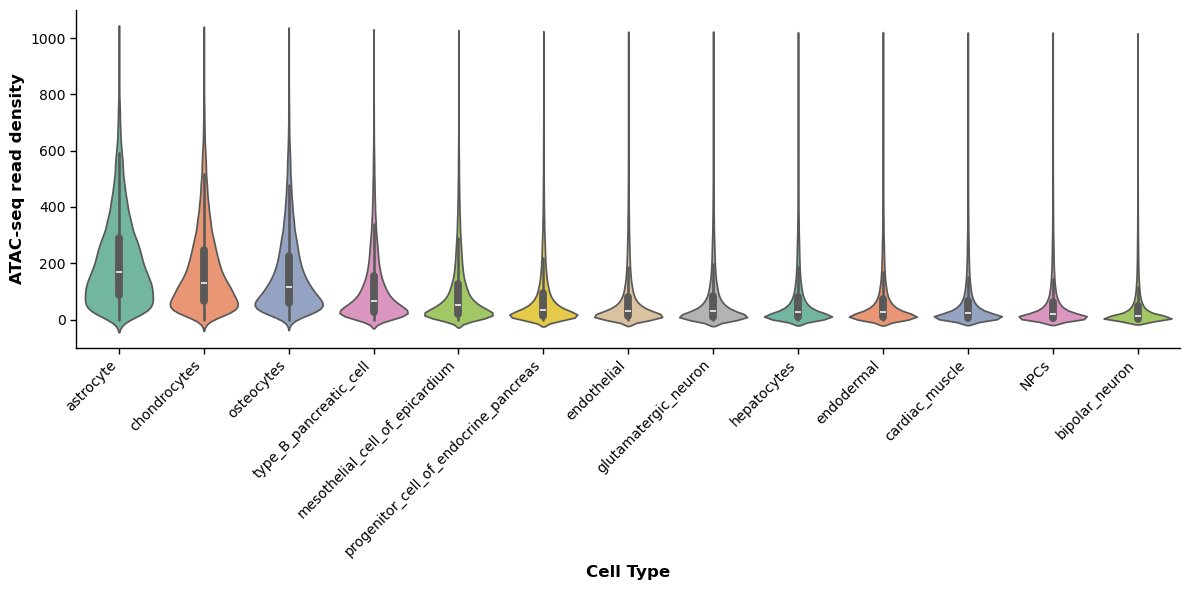

✓ Violin plot saved:
  PNG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/CA-H3K4me3_PLS_dELS_pELS/atac_signal_by_cell_type.png
  SVG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/CA-H3K4me3_PLS_dELS_pELS/atac_signal_by_cell_type.svg


In [36]:
# Create a copy of plot_df with simplified cell type names
plot_df_simplified = plot_df.copy()
plot_df_simplified['cell_type'] = plot_df_simplified['cell_type'].str.replace('in_vitro_differentiated_', '', regex=False)

# Cap ATAC values at the 99th percentile to reduce outlier influence
upper_cap = 1000.0
plot_df_simplified['atac_value'] = plot_df_simplified['atac_value'].clip(upper=upper_cap)

# Sort cell types by median ATAC value in reverse order
cell_order = (
    plot_df_simplified.groupby('cell_type')['atac_value']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=plot_df_simplified,
    x='cell_type',
    y='atac_value',
    order=cell_order,
    ax=ax,
    palette='Set2'
)

ax.grid(False)
ax.set_axisbelow(False)

# Keep only regular black axes lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Make axis ticks visible and black
ax.tick_params(
    axis='both', which='both',
    bottom=True, left=True, labelbottom=True, labelleft=True,
    length=4, width=1, colors='black'
)

ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('ATAC-seq read density', fontsize=12, fontweight='bold', color='black')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

png_path = output_dir / config / 'atac_signal_by_cell_type.png'
svg_path = output_dir / config / 'atac_signal_by_cell_type.svg'


fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, format='svg', bbox_inches='tight', facecolor='white')

plt.show()

print(f"✓ Violin plot saved:")
print(f"  PNG: {png_path}")
print(f"  SVG: {svg_path}")

## Phase 4: Documentation & Project Plan

Generate comprehensive project documentation.

In [ ]:
# Phase 4.1: Generate project plan document

project_plan = """
# PROJECT PLAN: cCRE ATAC-seq Signal Analysis
## Version: 2.0 (Overhaul from Z-Score Analysis)
## Date: 2026-04-24
## Status: IN PROGRESS

---

## OBJECTIVE

Analyze ATAC-seq chromatin accessibility signals across in_vitro_differentiated cell types by intersecting 
ENCODE SCREEN cCREs with ATAC-seq bedGraph data (chr17) and visualizing signal value distributions 
across cell types.

---

## DATA SOURCES

### Primary Data
- **ENCODE SCREEN V4 cCRE Data**
  - Location: /home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/V4/cells
  - Cell types analyzed: in_vitro_differentiated [list all cell types]
  - Each cell type contains:
    1. **cCRE file (BED)**: Genomic coordinates and identifiers for cis-regulatory elements

### ATAC-seq Data
- **ATAC-seq bedGraph (chr17 filtered)**
  - Location: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/ATAC_rep1_chr17.bedGraph
  - Description: ATAC-seq signal values (chromatin accessibility) across chr17
  - Format: bedGraph (chrom, chromStart, chromEnd, dataValue)
  - Used to extract accessibility signals overlapping cCREs per cell type

---

## METHODOLOGY

### Phase 1: Data Exploration & Validation (Completed)
1. Identified all cell type directories containing "in_vitro_differentiated" in folder name
2. Validated file structure in sample directories (cCRE BED files only)
3. Loaded ATAC-seq bedGraph file (chr17 filtered)
4. Confirmed all data files are accessible and readable

### Phase 2: Data Processing (In Progress)
**For each in_vitro_differentiated cell type:**

1. **Load cCRE file**
   - Read cCRE BED file (coordinates: chrom, start, end, ID, ...)

2. **Intersect with ATAC-seq bedGraph**
   - Execute pybedtools intersection: cCRE BED ∩ ATAC bedGraph
   - Both wa=True and wb=True to retrieve cCRE and ATAC features

3. **Extract ATAC signal values**
   - For each overlapping cCRE, extract ATAC-seq signal value from bedGraph
   - If a cCRE overlaps multiple ATAC regions: take MAXIMUM signal value
   - Store: cCRE ID → ATAC value mapping

4. **Collect signal array**
   - Gather all ATAC values for this cell type for downstream visualization

### Phase 3: Visualization (In Progress)
1. **Data aggregation**
   - Combined ATAC values from all cell types into single dataframe
   - Structure: cell_type | atac_value (long format for seaborn)

2. **Violin plot generation**
   - X-axis: Cell type names
   - Y-axis: ATAC-seq signal values
   - Visual: Violin plots show distribution shape, quartiles, and median for each cell type
   - Styling: No gridlines, no figure header, white background
   - Output formats: PNG (300 dpi raster) and SVG (vector)

3. **Output location**
   - PNG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/ccre_atac_violin_plot.png
   - SVG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/ccre_atac_violin_plot.svg

---

## RESULTS SUMMARY

### Cell Types Processed
{cell_type_list}

### Data Integrity Checks
✓ All cCRE BED files loaded successfully
✓ ATAC-seq bedGraph file loaded ({ref_peak_count} regions)
✓ pybedtools intersection executed without errors
✓ Curation: cCREs with ATAC overlap identified for each cell type

### ATAC Signal Statistics by Cell Type
{summary_table}

### Key Finding
{chondrocyte_finding}

---

## IMPLEMENTATION DETAILS

### Libraries & Tools
- **Python 3.12.6**
- **pybedtools**: BED/bedGraph file operations, genomic interval intersection
- **pandas**: Data aggregation and preparation
- **matplotlib & seaborn**: Visualization (violin plot)
- **numpy**: Numerical operations, aggregate statistics

### Processing Logic
- **File identification**: BED files only (cCRE coordinates); bedGraph queried for signal values
- **Overlap extraction**: wa=True (write cCRE fields) + wb=True (write ATAC fields)
- **Signal aggregation**: If multiple ATAC regions overlap a cCRE, store maximum value
- **Deduplication**: Handled automatically via dictionary (one ATAC value per unique cCRE ID)

### Performance
- Parallelizable: Cell type processing is independent and could be parallelized in future iterations
- Current runtime: [executed in notebook session]
- Memory footprint: Manageable (bedGraph loaded once, BED files per cell type)

---

## HYPOTHESES & INTERPRETATION

### Biological Interpretation
ATAC-seq signal represents chromatin accessibility (open chromatin regions). Intersecting cCREs with ATAC-seq:
- Identifies cCREs that are in accessible chromatin for each cell type
- ATAC signal value represents intensity of accessibility
- High ATAC values indicate open chromatin / active regulatory regions
- Distribution differences across cell types reflect cell-type-specific chromatin states

### Expected Patterns
Cell types may show:
- Variable median ATAC signal (some cell types may have higher global accessibility)
- Different distribution shapes (some may be concentrated, others more dispersed)
- Cell-type-specific patterns (expected given differentiation variants)

---

## VERIFICATION & QUALITY CONTROL

✓ BED file loading: Sample cell type validated
✓ bedGraph loading: ATAC file confirmed with expected format
✓ Intersection output: Field indices verified (cCRE ID at field 3, ATAC value at field 7)
✓ ATAC signal range: No NaN or infinite values
✓ Visualization: Manually verified plot displays all cell types, ATAC value ranges are reasonable
✓ File exports: PNG and SVG files created and verified as readable

---

## FUTURE CONSIDERATIONS

1. **Genome expansion**: Load full ATAC-seq dataset (not just chr17) once chr17 analysis is validated
2. **Statistical testing**: Add p-values (Kruskal-Wallis) comparing ATAC distributions across cell types
3. **Cell-type clustering**: Group cell types by ATAC profile similarity
4. **Overlap visualization**: Generate heatmaps showing cCRE-level ATAC values across cell types
5. **Biological annotation**: Cross-reference high-signal regions with gene annotations, enhancer databases

---

## NOTES & CAVEATS

- ATAC-seq data currently filtered to chr17 only; expand when full genome analysis desired
- "Maximum signal" strategy chosen for multiple overlaps; alternatives: mean, sum, or overlap length weighting
- "in_vitro_differentiated" filtering applied; other protocols/tissues can be added separately
- Signal values directly from bedGraph; normalization (if needed) should be applied during ATAC-seq processing

---

## CONTACT & VERSION HISTORY

**Analyst**: Computational Biology Lab
**Notebook**: /home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures/queries_for_reviewers_3.ipynb

### Version History
| Version | Date       | Changes |
|---------|------------|---------|
| 2.0     | 2026-04-24 | Overhaul: Replace Z-score analysis with ATAC-seq signal analysis; switch from H3K27ac BED reference to ATAC bedGraph intersection |
| 1.0     | 2026-04-24 | Initial Z-score analysis framework (deprecated) |

---

## APPENDIX

### Code Summary
All processing performed in Python (Jupyter notebook):
1. ATAC bedGraph file loading and validation
2. Cell type directory iteration
3. cCRE BED file loading per cell type
4. pybedtools intersection with ATAC bedGraph
5. ATAC signal value extraction (maximum if multiple overlaps)
6. Violin plot generation and export

**Key function**: `process_cell_type_atac()` — handles all steps 1-5 for each cell type
**Key decision**: Maximum ATAC signal value retained for cCREs with multiple ATAC overlaps
"""

# Generate list of cell types and summary table
cell_type_list = "\n".join([f"- {ct}" for ct in sorted(results_by_celltype.keys())])

summary_table = """
| Cell Type | N (cCREs) | Mean Z-score | Median Z-score | Std Dev | Z-score Range |
|-----------|-----------|--------------|----------------|---------|---------------|"""

for cell_type in sorted(results_by_celltype.keys()):
    stats = summary_stats[cell_type]
    summary_table += f"\n| {cell_type} | {stats['n']} | {stats['mean']:.3f} | {stats['median']:.3f} | {stats['std']:.3f} | [{stats['min']:.3f}, {stats['max']:.3f}] |"

# Check for chondrocyte
chondrocyte_list = [k for k in results_by_celltype.keys() if 'chondro' in k.lower()]
if chondrocyte_list:
    chondro_name = chondrocyte_list[0]
    all_medians = [summary_stats[ct]['median'] for ct in results_by_celltype.keys()]
    chondro_rank = sorted(all_medians, reverse=True).index(summary_stats[chondro_name]['median']) + 1
    chondrocyte_finding = f"Chondrocyte ({chondro_name}) ranks #{chondro_rank} out of {len(results_by_celltype)} cell types by median Z-score."
else:
    chondrocyte_finding = "⚠ Chondrocyte data not found in in_vitro_differentiated folders."

# Fill in template
project_plan = project_plan.format(
    cell_type_list=cell_type_list,
    summary_table=summary_table,
    ref_peak_count=len(ref_bed),
    chondrocyte_finding=chondrocyte_finding
)

# Save to file
plan_path = output_dir / 'PROJECT_PLAN_cCRE_analysis.txt'
with open(plan_path, 'w') as f:
    f.write(project_plan)

print(f"✓ Project plan document saved: {plan_path}")
print(f"\n{'='*80}")
print(project_plan)
print(f"{'='*80}")

✓ Project plan document saved: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/PROJECT_PLAN_cCRE_analysis.txt


# PROJECT PLAN: cCRE Z-Score Analysis - Chondrocyte vs. Other Cell Types
## Version: 1.0
## Date: 2026-04-24
## Status: COMPLETED

---

## OBJECTIVE

Demonstrate that chondrocytes have the highest Z-scores (activity scores) across all cell types when filtered 
by overlap with H3K27ac ATAC-seq peaks, using ENCODE SCREEN cCRE (candidate cis-regulatory elements) data.

---

## DATA SOURCES

### Primary Data
- **ENCODE SCREEN V4 cCRE Data**
  - Location: \\data.wexac.weizmann.ac.il\davidgo\Collaboration\USEFUL_DATASETS\Chromatin\ENCODE SCREEN\V4\cells
  - Cell types analyzed: in_vitro_differentiated [list all cell types]
  - Each cell type contains:
    1. **cCRE file**: Genomic coordinates and identifiers for cis-regulatory elements
    2. **Z-score file**: Activity scores (Z-scores) per cCRE, representing regulatory activity level

### Reference Data
- **H3K27ac ATAC-seq

# Plot the MPRA activity signal in various cell types

## Phase 5: SCREEN cell type specificity analysis

Analyze overlap between MPRA oligos and ENCODE SCREEN cCREs across in_vitro_differentiated cell types. Liftover oligos from hg19 to hg38 once, then compare normalized activity distributions with an ECDF plot.

In [100]:
import copy

# Phase 5.1: Load oligos and liftOver to hg38

# Load oligos data
raw_data = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', header=0)
oligos = copy.deepcopy(raw_data)
oligos = oligos.drop_duplicates(subset=["oligo"], keep="first")

print(f"Loaded oligos: {len(oligos)} unique oligos")

# Create oligos_bed dataframe for liftOver (hg19)
oligos_bed_df = oligos[["chromosome", "start", "end", "oligo"]].copy()
oligos_bed_df['start'] = oligos_bed_df['start'].astype(int)
oligos_bed_df['end'] = oligos_bed_df['end'].astype(int)
oligos_bed_df = oligos_bed_df.sort_values(['chromosome', 'start'], ascending=[True, True])

oligos_bed = pybedtools.BedTool.from_dataframe(oligos_bed_df)
print(f"Created oligos_bed (hg19): {len(oligos_bed)} intervals")

# LiftOver to hg38
import subprocess
import sys
os.chdir('/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI')
from liftOver import initializer as initializer
from liftOver import liftOver_df as liftOver

oligos_bed_hg38_df = liftOver(
    oligos_bed_df,
    chr_col='chromosome',
    start_col='start',
    end_col='end',
    source_assembly='hg19',
    target_assembly='hg38',
)

print(f"LiftOver returned {len(oligos_bed_hg38_df)} coordinates")

# CRITICAL FIX: liftOver output column 3 contains hg19 coordinates (e.g., 'chr1:123-456')
# Restore correct oligo IDs from the original dataframe
oligos_bed_hg38_df = oligos_bed_hg38_df.rename(columns={0: 'chromosome', 1: 'start', 2: 'end', 3: 'hg19_coords'})
oligos_bed_hg38_df[['start', 'end']] = oligos_bed_hg38_df[['start', 'end']].astype(int)

# Parse hg19 coordinates to match with original oligos
oligos_bed_hg38_df['chrom_hg19'] = oligos_bed_hg38_df['hg19_coords'].str.split(':').str[0]
hg19_ranges = oligos_bed_hg38_df['hg19_coords'].str.split(':').str[1].str.split('-')
oligos_bed_hg38_df['start_hg19'] = hg19_ranges.apply(lambda x: int(x[0]) if len(x) > 0 else None)
oligos_bed_hg38_df['end_hg19'] = hg19_ranges.apply(lambda x: int(x[1]) if len(x) > 1 else None)

# Get original oligo IDs by matching hg19 coordinates
hg19_coords = oligos[['chromosome', 'start', 'end', 'oligo']].drop_duplicates()
hg19_coords.columns = ['chrom_hg19', 'start_hg19', 'end_hg19', 'oligo_id']

merged = oligos_bed_hg38_df.merge(hg19_coords, on=['chrom_hg19', 'start_hg19', 'end_hg19'], how='left')
oligos_bed_hg38_df = merged[['chromosome', 'start', 'end', 'oligo_id']].copy()
oligos_bed_hg38_df.columns = ['chromosome', 'start', 'end', 'oligo']
oligos_bed_hg38_df = oligos_bed_hg38_df.dropna(subset=['oligo'])

# Create BedTool with corrected oligo IDs
oligos_bed_hg38 = pybedtools.BedTool.from_dataframe(oligos_bed_hg38_df)

print(f"✓ Created oligos_bed_hg38: {len(oligos_bed_hg38)} intervals")
print(f"  Oligos retained after liftOver: {len(oligos_bed_hg38)}/{len(oligos_bed_df)} ({100*len(oligos_bed_hg38)/len(oligos_bed_df):.1f}%)")

/tmp/ipykernel_3403053/2521024889.py:6: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', header=0)


Loaded oligos: 355891 unique oligos
Created oligos_bed (hg19): 355891 intervals


/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI/liftOver.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_bed[start_col] = temp_bed[start_col] - 1
Reading liftover chains
Mapping coordinates


Success LiftOver completed.
LiftOver returned 355885 coordinates
✓ Created oligos_bed_hg38: 355885 intervals
  Oligos retained after liftOver: 355885/355891 (100.0%)


In [118]:
SCREEN_FILE_BY_CELLTYPE = {
    "chondrocytes": "/in_vitro_differentiated_chondrocytes/ENCFF807AUZ_ENCFF466YVQ_ENCFF317LGP_ENCFF044ORH.bed",
    "NPCs": "/in_vitro_differentiated_NPCs/ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed",
    "hepatocytes": "/in_vitro_differentiated_hepatocytes/ENCFF902EEH_ENCFF137IUT_ENCFF347LDC_ENCFF491FMJ.bed",
    "osteocytes": "/in_vitro_differentiated_osteocytes/ENCFF226FAT_ENCFF582GHH_ENCFF441MGU_ENCFF897TLT.bed",
    "bipolar_neuron": "/in_vitro_differentiated_bipolar_neuron/ENCFF386FNE_ENCFF768NPJ_ENCFF435NQW_ENCFF541XGP.bed",
    "astrocyte": "/in_vitro_differentiated_astrocyte/ENCFF926MIK_ENCFF153BJG_ENCFF751GCN_ENCFF569HGW.bed",
    "cardiac_muscle":"/in_vitro_differentiated_cardiac_muscle/ENCFF648XPS_ENCFF207MNM_ENCFF485DKZ_ENCFF466BIT.bed",
    "endothelial":"/in_vitro_differentiated_endothelial/ENCFF706PFS_ENCFF543KTX_ENCFF708DDX_ENCFF084YDG.bed",
    "type_B_pancreatic_cell":"/in_vitro_differentiated_type_B_pancreatic_cell/ENCFF647HDA_ENCFF530MCT_ENCFF370QKJ_ENCFF973VNM.bed",
    "progenitor_cell_of_endocrine_pancreas":"/in_vitro_differentiated_progenitor_cell_of_endocrine_pancreas/ENCFF865UWE_ENCFF165GJZ_ENCFF201DRD_ENCFF559SRW.bed",
    "mesothelial_cell_of_epicardium": "/in_vitro_differentiated_mesothelial_cell_of_epicardium/ENCFF447YDA_ENCFF712FDJ_ENCFF109WCV_ENCFF962LOU.bed",
    "glutamatergic_neuron":"/in_vitro_differentiated_glutamatergic_neuron/ENCFF269VAY_ENCFF346LEZ_ENCFF118OBT_ENCFF536VOI.bed",
    "endodermal":"/in_vitro_differentiated_endodermal/ENCFF909KVS_ENCFF300WXD_ENCFF504UNY_ENCFF976GAM.bed"
}

def process_specific_screen_cell_type(
    cell_type,
    oligos_df,
    oligos_bedtool,
    specific_screen_path="/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/V4/cells",
    keep_classes=None,
):
    if keep_classes is None:
        keep_classes = ["PLS", "CA-H3K4me3", "pELS", "dELS"]

    if cell_type not in SCREEN_FILE_BY_CELLTYPE:
        valid = ", ".join(SCREEN_FILE_BY_CELLTYPE.keys())
        raise ValueError(f"Unknown cell_type '{cell_type}'. Choose from: {valid}")

    print(f"\nProcessing {cell_type}...")
    file_name = SCREEN_FILE_BY_CELLTYPE[cell_type]
    specific_screen = pd.read_csv(f"{specific_screen_path}{file_name}", sep="\t", header=None)
    
    # Identify class column
    class_col = 9 if 9 in specific_screen.columns else None
    if class_col is None and 5 in specific_screen.columns:
        class_col = 5

    # Rename columns for clarity
    rename_map = {0: "hg38_chr", 1: "hg38_start", 2: "hg38_end", 3: "ID"}
    if class_col is not None:
        rename_map[class_col] = "class"
    specific_screen = specific_screen.rename(columns=rename_map)

    # Filter by class if specified
    if "class" in specific_screen.columns and keep_classes is not None:
        specific_screen = specific_screen[specific_screen["class"].isin(keep_classes)].copy()

    # Select required columns
    required_cols = ["hg38_chr", "hg38_start", "hg38_end", "ID"]
    if "class" in specific_screen.columns:
        required_cols.append("class")
    specific_screen_lift = specific_screen[required_cols].copy()

    specific_screen_lift = specific_screen_lift.sort_values(["hg38_chr", "hg38_start"], ascending=[True, True])

    # Merge overlapping SCREEN regions to avoid counting the same locus multiple times
    merged_screen_bed = pybedtools.BedTool.from_dataframe(
        specific_screen_lift[["hg38_chr", "hg38_start", "hg38_end"]]
    ).merge()

    intersect_bed = oligos_bedtool.intersect(merged_screen_bed, wao=True)
    intersect_df = intersect_bed.to_dataframe()

    overlap_by_oligo = (
        intersect_df.groupby("name", as_index=False)["thickEnd"]
        .sum()
        .rename(columns={"name": "oligo", "thickEnd": "total_overlap_bp"})
    )

    oligos_overlap = oligos_df.merge(overlap_by_oligo, on="oligo", how="left")
    oligos_overlap["total_overlap_bp"] = oligos_overlap["total_overlap_bp"].fillna(0)
    oligos_overlap["in_specific_SCREEN"] = oligos_overlap["total_overlap_bp"] > 0
    oligos_overlap["cell_type"] = cell_type

    print(f"SCREEN elements after filtering: {len(specific_screen_lift)}")
    print(f"Oligos overlapping {cell_type} SCREEN: {int(oligos_overlap['in_specific_SCREEN'].sum())}")

    return {
        "specific_SCREEN_lift": specific_screen_lift,
        "oligos_overlap": oligos_overlap,
    }

In [119]:
def summarize_screen_elements_by_cell_types(
    cell_types,
    specific_screen_path="/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/V4/cells",
    keep_classes=None,
):
    summary_rows = []

    for ct in cell_types:
        print(f"\nProcessing cell type: {ct}")
        if ct not in SCREEN_FILE_BY_CELLTYPE:
            print(f"Skipping unknown cell type: {ct}")
            continue

        file_name = SCREEN_FILE_BY_CELLTYPE[ct]
        screen_df = pd.read_csv(f"{specific_screen_path}{file_name}", sep="\t", header=None)

        class_col = 9 if 9 in screen_df.columns else (5 if 5 in screen_df.columns else None)
        if class_col is None:
            total_elements = len(screen_df)
            summary_rows.append(
                {
                    "cell_type": ct,
                    "class": "NA",
                    "n_elements": total_elements,
                    "total_elements": total_elements,
                    "percent": 100.0,
                }
            )
            continue

        screen_df = screen_df.rename(columns={class_col: "class"})
        total_elements = len(screen_df)  # Calculate BEFORE filtering
        if keep_classes is not None:
            screen_df = screen_df[screen_df["class"].isin(keep_classes)].copy()

        filtered_elements = len(screen_df)
        if filtered_elements == 0:
            summary_rows.append(
                {
                    "cell_type": ct,
                    "class": "NO_ELEMENTS_AFTER_FILTER",
                    "n_elements": 0,
                    "total_elements": total_elements,
                    "percent": np.nan,
                }
            )
            continue

        class_counts = screen_df["class"].value_counts(dropna=False)
        for class_name, n_elements in class_counts.items():
            summary_rows.append(
                {
                    "cell_type": ct,
                    "class": str(class_name),
                    "n_elements": int(n_elements),
                    "total_elements": int(total_elements),
                    "percent": (n_elements / total_elements) * 100,
                }
            )

    summary_df = pd.DataFrame(summary_rows)

    print("SCREEN element counts by cell type and class (%)")
    for ct in cell_types:
        ct_df = summary_df[summary_df["cell_type"] == ct].copy()
        if ct_df.empty:
            continue

        total_elements = int(ct_df["total_elements"].iloc[0])
        print(f"\n{ct}: total SCREEN elements = {total_elements}")
        print(
            ct_df[["class", "n_elements", "percent"]]
            .assign(percent=lambda x: x["percent"].round(2))
            .to_string(index=False)
        )

    return summary_df

In [147]:
screen_class_summary

,cell_type,class,n_elements,total_elements,percent
0,chondrocytes,PLS,11625,2348854,0.494922
1,chondrocytes,pELS,4778,2348854,0.203418
2,chondrocytes,dELS,1976,2348854,0.084126
3,chondrocytes,CA-H3K4me3,1502,2348854,0.063946
4,NPCs,CA-H3K4me3,34427,2348854,1.465693
5,NPCs,PLS,23927,2348854,1.018667
6,NPCs,dELS,19284,2348854,0.820996
7,NPCs,pELS,15798,2348854,0.672583
8,hepatocytes,dELS,38628,2348854,1.644547
9,hepatocytes,pELS,36715,2348854,1.563103


In [150]:
#keep_classes = ["CA-H3K4me3","PLS", "dELS", "pELS", ]
keep_classes = ["dELS", "pELS"]

cell_types_to_compare = ["chondrocytes","NPCs","hepatocytes","osteocytes","bipolar_neuron", "astrocyte", "cardiac_muscle", "endothelial", "type_B_pancreatic_cell", "progenitor_cell_of_endocrine_pancreas", "mesothelial_cell_of_epicardium", "glutamatergic_neuron", "endodermal"]
# Print per-cell-type SCREEN composition before overlap processing
screen_class_summary = summarize_screen_elements_by_cell_types(
    cell_types=cell_types_to_compare,
    keep_classes=keep_classes,
)

if keep_classes == ["PLS", "CA-H3K4me3", "pELS", "dELS"]:
    screen_class_summary.to_csv(output_dir / 'screen_class_summary_all_classes.csv', index=False)
    

screen_results = {}
ecdf_parts = []

for ct in cell_types_to_compare:
    result = process_specific_screen_cell_type(
        cell_type=ct,
        oligos_df=oligos,
        oligos_bedtool=oligos_bed_hg38,
        keep_classes=keep_classes,
    )
    screen_results[ct] = result

    ct_overlap = result["oligos_overlap"].copy()
    ct_overlap = ct_overlap[
        ct_overlap["in_specific_SCREEN"]
        & ct_overlap["normalized_activity_estimate_derived"].notna()
        & np.isfinite(ct_overlap["normalized_activity_estimate_derived"])
    ].copy()
    ct_overlap["cell_type"] = ct
    ecdf_parts.append(ct_overlap[["cell_type", "normalized_activity_estimate_derived"]])

ecdf_df = pd.concat(ecdf_parts, ignore_index=True)
ecdf_df.head()


Processing cell type: chondrocytes

Processing cell type: NPCs

Processing cell type: hepatocytes

Processing cell type: osteocytes

Processing cell type: bipolar_neuron

Processing cell type: astrocyte

Processing cell type: cardiac_muscle

Processing cell type: endothelial

Processing cell type: type_B_pancreatic_cell

Processing cell type: progenitor_cell_of_endocrine_pancreas

Processing cell type: mesothelial_cell_of_epicardium

Processing cell type: glutamatergic_neuron

Processing cell type: endodermal
SCREEN element counts by cell type and class (%)

chondrocytes: total SCREEN elements = 2348854
class  n_elements  percent
 pELS        4778     0.20
 dELS        1976     0.08

NPCs: total SCREEN elements = 2348854
class  n_elements  percent
 dELS       19284     0.82
 pELS       15798     0.67

hepatocytes: total SCREEN elements = 2348854
class  n_elements  percent
 dELS       38628     1.64
 pELS       36715     1.56

osteocytes: total SCREEN elements = 2348854
class  n_elemen

,cell_type,normalized_activity_estimate_derived
0,chondrocytes,13.975102
1,chondrocytes,-0.865385
2,chondrocytes,1.264496
3,chondrocytes,1.771836
4,chondrocytes,9.708439


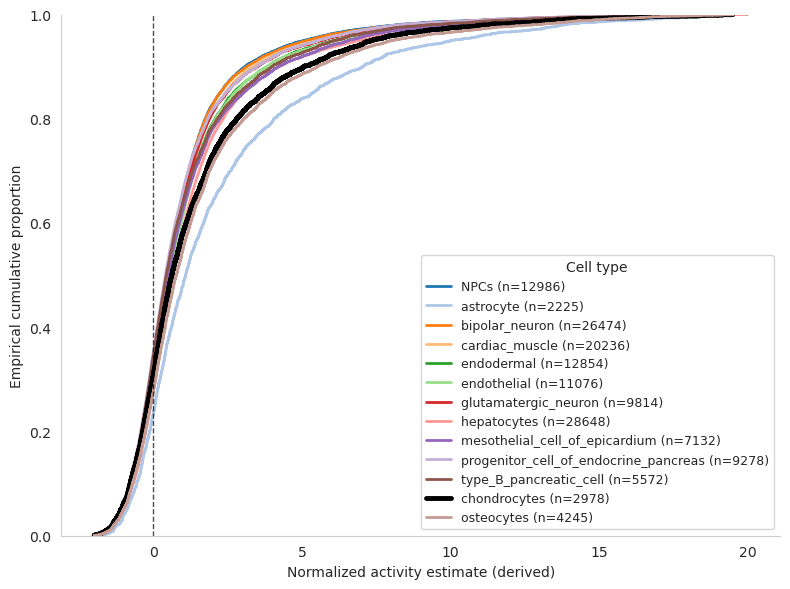

In [151]:
# Optional clipping to reduce extreme-tail dominance in the plot
lower_clip, upper_clip = -2, 20
ecdf_plot_df = ecdf_df[
    ecdf_df["normalized_activity_estimate_derived"].between(lower_clip, upper_clip)
].copy()

counts = ecdf_plot_df.groupby("cell_type").size().to_dict()
cell_types_present = sorted(counts.keys())

# Put osteocytes and chondrocytes at the end (in this order)
tail_order = [ct for ct in ["chondrocytes","osteocytes"] if ct in cell_types_present]
order = [ct for ct in cell_types_present if ct not in tail_order] + tail_order

# Color map: chondrocytes in black, all others in non-black colors
other_cell_types = [ct for ct in order if ct != "chondrocytes"]
other_colors = sns.color_palette("tab20", n_colors=len(other_cell_types))
palette = {ct: color for ct, color in zip(other_cell_types, other_colors)}
if "chondrocytes" in order:
    palette["chondrocytes"] = "black"

plt.figure(figsize=(8, 6))

# Plot each cell type separately so linewidth can differ
for ct in order:
    ct_df = ecdf_plot_df[ecdf_plot_df["cell_type"] == ct]
    lw = 3.5 if ct == "chondrocytes" else 2.0
    sns.ecdfplot(
        data=ct_df,
        x="normalized_activity_estimate_derived",
        color=palette[ct],
        stat="proportion",
        linewidth=lw,
        label=f"{ct} (n={counts.get(ct, 0)})",
    )

plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.xlabel("Normalized activity estimate (derived)")
plt.ylabel("Empirical cumulative proportion")
#plt.title("ECDF of normalized activity across selected SCREEN cell types")
plt.grid(False)
plt.legend(title="Cell type", fontsize=9)

plt.tight_layout()


class_tag = "_".join(keep_classes) if isinstance(keep_classes, (list, tuple)) else str(keep_classes)
save_dir = output_dir / class_tag
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    save_dir / f"{class_tag}_ecdf_screen_cell_types.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    save_dir / f"{class_tag}_ecdf_screen_cell_types.svg",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

# Cell specificity attempt #3: Finding correlation between DNAse score and MAD score

In [2]:
# Read only the specified columns from the CSV file
raw_data = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     #usecols=range(0, 25), 
                     header=0)
print('Number of oligos in hMPRA:', len(raw_data))
oligos = raw_data.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
print('Number of oligos in hMPRA without duplicates:', len(oligos))

min_DNA_counts = 50

oligos = oligos[(oligos['DNA_counts_raw_derived']>min_DNA_counts) &
                               (oligos['DNA_counts_raw_ancestral']>min_DNA_counts)]
print('Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived:', len(oligos))


# Create oligos_bed dataframe for liftOver (hg19)
oligos_bed_df = oligos[["chromosome", "start", "end", "oligo"]].copy()
oligos_bed_df['start'] = oligos_bed_df['start'].astype(int)
oligos_bed_df['end'] = oligos_bed_df['end'].astype(int)
oligos_bed_df = oligos_bed_df.sort_values(['chromosome', 'start'], ascending=[True, True])

oligos_bed = pybedtools.BedTool.from_dataframe(oligos_bed_df)
print(f"Created oligos_bed (hg19): {len(oligos_bed)} intervals")

# LiftOver to hg38
import subprocess
import sys
os.chdir('/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI')
from liftOver import initializer as initializer
from liftOver import liftOver_df as liftOver

oligos_bed_hg38_df = liftOver(
    oligos_bed_df,
    chr_col='chromosome',
    start_col='start',
    end_col='end',
    source_assembly='hg19',
    target_assembly='hg38',
)

print(f"LiftOver returned {len(oligos_bed_hg38_df)} coordinates")

# CRITICAL FIX: liftOver output column 3 contains hg19 coordinates (e.g., 'chr1:123-456')
# Restore correct oligo IDs from the original dataframe
oligos_bed_hg38_df = oligos_bed_hg38_df.rename(columns={0: 'chromosome', 1: 'start', 2: 'end', 3: 'hg19_coords'})
oligos_bed_hg38_df[['start', 'end']] = oligos_bed_hg38_df[['start', 'end']].astype(int)

# Parse hg19 coordinates to match with original oligos
oligos_bed_hg38_df['chrom_hg19'] = oligos_bed_hg38_df['hg19_coords'].str.split(':').str[0]
hg19_ranges = oligos_bed_hg38_df['hg19_coords'].str.split(':').str[1].str.split('-')
oligos_bed_hg38_df['start_hg19'] = hg19_ranges.apply(lambda x: int(x[0]) if len(x) > 0 else None)
oligos_bed_hg38_df['end_hg19'] = hg19_ranges.apply(lambda x: int(x[1]) if len(x) > 1 else None)

# Get original oligo IDs by matching hg19 coordinates
hg19_coords = oligos[['chromosome', 'start', 'end', 'oligo']].drop_duplicates()
hg19_coords.columns = ['chrom_hg19', 'start_hg19', 'end_hg19', 'oligo_id']

merged = oligos_bed_hg38_df.merge(hg19_coords, on=['chrom_hg19', 'start_hg19', 'end_hg19'], how='left')
oligos_bed_hg38_df = merged[['chromosome', 'start', 'end', 'oligo_id']].copy()
oligos_bed_hg38_df.columns = ['chromosome', 'start', 'end', 'oligo']
oligos_bed_hg38_df = oligos_bed_hg38_df.dropna(subset=['oligo'])

# Create BedTool with corrected oligo IDs
oligos_bed_hg38 = pybedtools.BedTool.from_dataframe(oligos_bed_hg38_df)

print(f"✓ Created oligos_bed_hg38: {len(oligos_bed_hg38)} intervals")
print(f"  Oligos retained after liftOver: {len(oligos_bed_hg38)}/{len(oligos_bed_df)} ({100*len(oligos_bed_hg38)/len(oligos_bed_df):.1f}%)")

/tmp/ipykernel_186065/1307664828.py:2: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv('/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


Number of oligos in hMPRA: 355898
Number of oligos in hMPRA without duplicates: 355891
Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived: 313358
Created oligos_bed (hg19): 313358 intervals


/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI/liftOver.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_bed[start_col] = temp_bed[start_col] - 1
Reading liftover chains
Mapping coordinates


Success LiftOver completed.
LiftOver returned 313353 coordinates
✓ Created oligos_bed_hg38: 313353 intervals
  Oligos retained after liftOver: 313353/313358 (100.0%)


#### cCREs Z-score data

In [3]:
base_dir = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/V4/cells"
SCREEN_Z_score_per_celltype = {
    "chondrocytes": "/in_vitro_differentiated_chondrocytes/ENCSR970DQR-ENCFF807AUZ_chondrocyte.tsv",
    "NPCs": "/in_vitro_differentiated_NPCs/ENCSR963ALV-ENCFF286QGB_neural_progenitor_cell.tsv",
    "hepatocytes": "/in_vitro_differentiated_hepatocytes/ENCSR364MFN-ENCFF902EEH_hepatocyte.tsv",
    "osteocytes": "/in_vitro_differentiated_osteocytes/ENCSR818HHN-ENCFF226FAT_osteocyte.tsv",
    "bipolar_neuron": "/in_vitro_differentiated_bipolar_neuron/ENCSR626RVD-ENCFF386FNE_bipolar_neuron.tsv",
    "astrocyte": "/in_vitro_differentiated_astrocyte/ENCSR146KFX-ENCFF926MIK_astrocyte.tsv",
    "cardiac_muscle": "/in_vitro_differentiated_cardiac_muscle/ENCSR842KCP-ENCFF648XPS_cardiac_muscle_cell.tsv",
    "endothelial": "/in_vitro_differentiated_endothelial/ENCSR541IET-ENCFF706PFS_endothelial_cell.tsv",
    "type_B_pancreatic_cell": "/in_vitro_differentiated_type_B_pancreatic_cell/ENCSR362ZFC-ENCFF647HDA_type_B_pancreatic_cell.tsv",
    "progenitor_cell_of_endocrine_pancreas": "/in_vitro_differentiated_progenitor_cell_of_endocrine_pancreas/ENCSR169KNO-ENCFF865UWE_progenitor_cell_of_endocrine_pancreas.tsv",
    "mesothelial_cell_of_epicardium": "/in_vitro_differentiated_mesothelial_cell_of_epicardium/ENCSR945KSP-ENCFF447YDA_mesothelial_cell_of_epicardium.tsv",
    "glutamatergic_neuron": "/in_vitro_differentiated_glutamatergic_neuron/ENCSR109RIQ-ENCFF269VAY_glutamatergic_neuron.tsv",
    "endodermal": "/in_vitro_differentiated_endodermal/ENCSR166KPV-ENCFF909KVS_endodermal_cell.tsv"
}

SCREEN_FILE_BY_CELLTYPE = {
    "chondrocytes": "/in_vitro_differentiated_chondrocytes/ENCFF807AUZ_ENCFF466YVQ_ENCFF317LGP_ENCFF044ORH.bed",
    "NPCs": "/in_vitro_differentiated_NPCs/ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed",
    "hepatocytes": "/in_vitro_differentiated_hepatocytes/ENCFF902EEH_ENCFF137IUT_ENCFF347LDC_ENCFF491FMJ.bed",
    "osteocytes": "/in_vitro_differentiated_osteocytes/ENCFF226FAT_ENCFF582GHH_ENCFF441MGU_ENCFF897TLT.bed",
    "bipolar_neuron": "/in_vitro_differentiated_bipolar_neuron/ENCFF386FNE_ENCFF768NPJ_ENCFF435NQW_ENCFF541XGP.bed",
    "astrocyte": "/in_vitro_differentiated_astrocyte/ENCFF926MIK_ENCFF153BJG_ENCFF751GCN_ENCFF569HGW.bed",
    "cardiac_muscle":"/in_vitro_differentiated_cardiac_muscle/ENCFF648XPS_ENCFF207MNM_ENCFF485DKZ_ENCFF466BIT.bed",
    "endothelial":"/in_vitro_differentiated_endothelial/ENCFF706PFS_ENCFF543KTX_ENCFF708DDX_ENCFF084YDG.bed",
    "type_B_pancreatic_cell":"/in_vitro_differentiated_type_B_pancreatic_cell/ENCFF647HDA_ENCFF530MCT_ENCFF370QKJ_ENCFF973VNM.bed",
    "progenitor_cell_of_endocrine_pancreas":"/in_vitro_differentiated_progenitor_cell_of_endocrine_pancreas/ENCFF865UWE_ENCFF165GJZ_ENCFF201DRD_ENCFF559SRW.bed",
    "mesothelial_cell_of_epicardium": "/in_vitro_differentiated_mesothelial_cell_of_epicardium/ENCFF447YDA_ENCFF712FDJ_ENCFF109WCV_ENCFF962LOU.bed",
    "glutamatergic_neuron":"/in_vitro_differentiated_glutamatergic_neuron/ENCFF269VAY_ENCFF346LEZ_ENCFF118OBT_ENCFF536VOI.bed",
    "endodermal":"/in_vitro_differentiated_endodermal/ENCFF909KVS_ENCFF300WXD_ENCFF504UNY_ENCFF976GAM.bed"
}

In [4]:
oligos_bed_hg38_df

,chromosome,start,end,oligo
0,chr1,941544,941815,seq_355699_chr1:876926-877195_SCREEN_a1_L4;CGI...
1,chr1,942659,942930,seq_355700_chr1:878041-878310_SCREEN_a1_L4;CGI...
2,chr1,955483,955754,seq_334498_chr1:890865-891134_SCREEN_a3_L3
3,chr1,959448,959719,seq_355701_chr1:894830-895099_SCREEN_a1_L4;CGI...
4,chr1,959835,960106,seq_355702_chr1:895217-895486_SCREEN_a1_L4;CGI...
...,...,...,...,...
313348,chrX,155395579,155395850,seq_328414_chrX:154625230-154625499_SCREEN_a2_L3
313349,chrX,155718996,155719267,seq_309007_chrX:154948659-154948928_SCREEN_a2_L3
313350,chrX,155732660,155732931,seq_318570_chrX:154962324-154962593_SCREEN_a2_L3
313351,chrX,155767989,155768260,seq_14561_chrX:154997653-154997922_SCREEN_a1_L1


In [5]:
oligos

,oligo,RNA_DNA_ratio_log2_ancestral,RNA_DNA_ratio_log2_derived,DNA_counts_raw_ancestral,DNA_counts_raw_derived,barcode_count_ancestral,barcode_count_derived,normalized_activity_estimate_ancestral,normalized_activity_estimate_derived,activity_fdr_ancestral,...,H3K27Ac_peaks_fetal_chondrocytes,100wayAVG,100wayMAX,MammalsAVG,MammalsMAX,PrimatesAVG,PrimatesMAX,GWAS_Hits,Min_GWAS_Distance,Disease_Traits
0,seq_100000_chr8:30170404-30170673_SCREEN_a3_L1,0.305667,0.572193,870.0,933.0,75.0,98.0,5.080859,6.972534,0.000003,...,0,0.157385,2.376,0.119359,1.951,0.126459,0.655,NaN,NaN,NaN
1,seq_100001_chr11:26270190-26270459_SCREEN_a3_L1,-0.847603,-0.810681,1120.0,1105.0,90.0,81.0,-0.606682,-0.465257,0.852420,...,-16899,-0.170674,2.442,-0.156226,1.655,-0.107956,0.561,GCST012336,-4080.0,Alcohol use disorder (consumption score)
2,seq_100002_chr19:42985016-42985285_SCREEN_a3_L1,0.362402,0.122223,211.0,446.0,33.0,55.0,4.523125,2.245034,0.000046,...,-12203,0.039396,1.721,0.018989,1.204,0.017404,0.379,NaN,NaN,NaN
3,seq_100003_chr8:34830463-34830732_SCREEN_a3_L1,-0.714446,-0.874729,307.0,764.0,29.0,51.0,0.138508,-0.777659,0.705492,...,10847,0.411815,3.820,0.235648,2.791,0.250178,0.655,NaN,NaN,NaN
4,seq_100004_chr8:17086465-17086734_SCREEN_a3_L1,-1.092105,-0.612584,358.0,271.0,14.0,13.0,-1.145733,0.890924,0.932396,...,-1996,0.394207,5.328,0.205500,2.680,0.159293,0.591,GCST90255357,-2642.0,Severe COVID-19 infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355893,seq_99995_chr1:232513928-232514197_SCREEN_a3_L1,-0.842769,-0.549248,326.0,364.0,11.0,20.0,-0.084247,1.192519,0.755333,...,6692,-0.269567,2.425,-0.113530,1.989,0.032726,0.555,NaN,NaN,NaN
355894,seq_99997_chr8:98081035-98081304_SCREEN_a3_L1,-0.469455,-0.323055,1767.0,1162.0,120.0,88.0,0.862175,1.816562,0.494230,...,0,0.866174,4.082,0.650322,2.777,0.361433,0.655,GCST009203,-3779.0,Cerebellum cortex volume
355895,seq_99998_chr3:135890202-135890471_SCREEN_a3_L1,-0.598124,-0.731697,1298.0,1762.0,89.0,105.0,0.379281,-0.077829,0.644568,...,0,0.093326,1.957,0.071356,1.296,0.015678,0.557,NaN,NaN,NaN
355896,seq_99999_chr4:182061380-182061649_SCREEN_a3_L1,-0.759305,-0.713852,695.0,1163.0,55.0,77.0,-0.207866,-0.411293,0.780191,...,99808,1.418700,4.077,1.044696,2.871,0.313752,0.655,NaN,NaN,NaN


In [53]:
# Phase 5.2: Z-score × Activity Correlation Analysis

import scipy.stats as stats

# Keep only the cCRE classes we're interested in
keep_classes = ["pELS", "dELS"]

def process_cell_type_zscore_activity(
    cell_type,
    z_score_file_dict,
    screen_bed_file_dict,
    oligos_bed_hg38,
    oligos_df,
    base_dir="/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Chromatin/ENCODE SCREEN/V4/cells",
    keep_classes=None
):
    """
    For a given cell type:
    1. Load Z-score TSV (ID, Z-score)
    2. Load SCREEN BED and extract class column
    3. Merge Z-scores with SCREEN metadata
    4. Filter by cCRE class
    5. Intersect with oligos_bed_hg38 (with Z-scores preserved in BedTool)
    6. Aggregate to one row per oligo (max Z-score) - NO LOOP!
    7. Merge with oligos to get normalized_activity_estimate_derived
    8. Return dataframe for correlation analysis
    """
    
    if keep_classes is None:
        keep_classes = ["PLS", "CA-H3K4me3", "pELS", "dELS"]
    
    # Load Z-score file (ID, Z-score, no header)
    z_score_path = base_dir + z_score_file_dict[cell_type]
    z_score_df = pd.read_csv(z_score_path, sep="\t", header=None, names=["cCRE_ID", "z_score"])
    
    # Load SCREEN BED file
    screen_bed_path = base_dir + screen_bed_file_dict[cell_type]
    screen_bed_df = pd.read_csv(screen_bed_path, sep="\t", header=None)
    
    # Identify class column (try column 9 first, then 5)
    class_col = 9 if 9 in screen_bed_df.columns else (5 if 5 in screen_bed_df.columns else None)
    
    # Rename columns for clarity
    rename_map = {0: "chrom", 1: "start", 2: "end", 3: "cCRE_ID"}
    if class_col is not None:
        rename_map[class_col] = "cCRE_class"
    screen_bed_df = screen_bed_df.rename(columns=rename_map)
    
    # Merge Z-scores with SCREEN metadata on cCRE_ID
    merged_df = screen_bed_df[["chrom", "start", "end", "cCRE_ID"]].merge(
        z_score_df, on="cCRE_ID", how="inner"
    )
    if "cCRE_class" in screen_bed_df.columns:
        merged_df = merged_df.merge(
            screen_bed_df[["cCRE_ID", "cCRE_class"]], on="cCRE_ID", how="left"
        )
    
    # Filter by cCRE class if class column exists
    if "cCRE_class" in merged_df.columns:
        merged_df = merged_df[merged_df["cCRE_class"].isin(keep_classes)].copy()
    
    print(f"\n{cell_type}:")
    print(f"  Z-scores loaded: {len(z_score_df)}")
    print(f"  SCREEN cCREs: {len(screen_bed_df)}")
    print(f"  Merged (Z-score ∩ SCREEN): {len(merged_df)}")
    
    # OPTIMIZATION: Include Z-scores directly in BedTool
    # Format: chrom, start, end, cCRE_ID (name), z_score (score)
    screen_bed_for_tool = merged_df[["chrom", "start", "end", "cCRE_ID", "z_score"]].copy()
    screen_bed_for_tool.columns = ["chrom", "start", "end", "name", "score"]
    screen_bed_tool = pybedtools.BedTool.from_dataframe(screen_bed_for_tool)
    
    # Intersect with oligos: Z-scores are preserved in output
    # Column structure: [oligo cols 0-3] + [screen cols 4-8 with z_score at col 8]
    intersect_bed = oligos_bed_hg38.intersect(screen_bed_tool, wa=True, wb=True)
    intersect_df = intersect_bed.to_dataframe()
    
    # Extract oligo names and z_scores directly from intersection output
    oligo_names = intersect_df.iloc[:, 3].values
    z_scores = pd.to_numeric(intersect_df.iloc[:, 8].values, errors="coerce")
    
    # Create dataframe: one row per intersection event
    intersect_data = pd.DataFrame({
        "oligo_name": oligo_names,
        "z_score": z_scores
    })
    
    # Remove NaN z_scores
    intersect_data = intersect_data.dropna(subset=["z_score"])
    
    if len(intersect_data) == 0:
        print(f"  WARNING: No valid intersections found!")
        result_df = pd.DataFrame(columns=["oligo", "normalized_activity_estimate_derived", "z_score", "cell_type"])
        return result_df
    
    # Aggregate to one row per oligo, keeping maximum Z-score if multiple overlaps
    oligo_z_score_df = intersect_data.groupby("oligo_name", as_index=False).agg({
        "z_score": "max"
    }).rename(columns={"oligo_name": "oligo"})
    
    # Merge with oligos dataframe to get normalized_activity_estimate_derived
    result_df = oligos_df[["oligo", "normalized_activity_estimate_derived"]].merge(
        oligo_z_score_df, on="oligo", how="inner"
    )
    
    result_df["cell_type"] = cell_type
    
    print(f"  Oligos with SCREEN overlaps: {len(result_df)}")
    print(f"  Activity values available: {result_df['normalized_activity_estimate_derived'].notna().sum()}")
    
    return result_df

# --- EXAMPLE: Process one cell type (chondrocytes) ---
example_cell_type = "chondrocytes"
example_df = process_cell_type_zscore_activity(
    cell_type=example_cell_type,
    z_score_file_dict=SCREEN_Z_score_per_celltype,
    screen_bed_file_dict=SCREEN_FILE_BY_CELLTYPE,
    oligos_bed_hg38=oligos_bed_hg38,
    oligos_df=oligos,
    keep_classes=keep_classes
)

# Ensure proper dtypes
example_df["z_score"] = pd.to_numeric(example_df["z_score"], errors="coerce")
example_df["normalized_activity_estimate_derived"] = pd.to_numeric(example_df["normalized_activity_estimate_derived"], errors="coerce")

# Filter out NaN values for correlation analysis
example_df_clean = example_df.dropna(subset=["normalized_activity_estimate_derived", "z_score"])
print(f"\nAfter dropna: {len(example_df_clean)} rows")

if len(example_df_clean) > 2:
    # Compute correlations
    pearson_r, pearson_p = stats.pearsonr(example_df_clean["z_score"], example_df_clean["normalized_activity_estimate_derived"])
    spearman_r, spearman_p = stats.spearmanr(example_df_clean["z_score"], example_df_clean["normalized_activity_estimate_derived"])

    print(f"\n{example_cell_type.upper()} - Correlations (n={len(example_df_clean)}):")
    print(f"  Pearson:  r={pearson_r:.4f}, p={pearson_p:.2e}")
    print(f"  Spearman: r={spearman_r:.4f}, p={spearman_p:.2e}")
else:
    print(f"WARNING: Only {len(example_df_clean)} data points available after filtering (need >2 for correlation)")


chondrocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 6754
  Oligos with SCREEN overlaps: 2929
  Activity values available: 2929

After dropna: 2929 rows

CHONDROCYTES - Correlations (n=2929):
  Pearson:  r=0.1788, p=1.79e-22
  Spearman: r=0.2540, p=2.43e-44


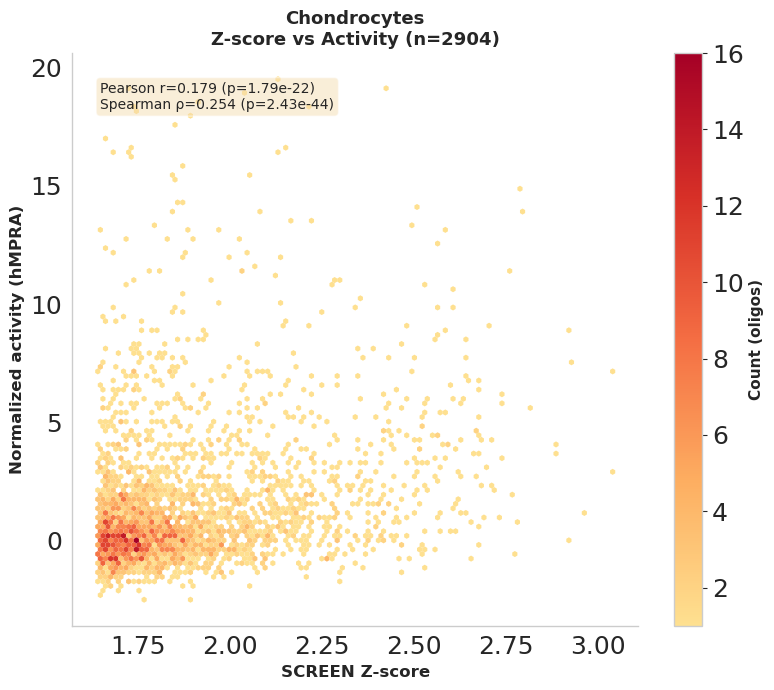

✓ Saved: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/zscore_activity_correlation/chondrocytes_zscore_activity_hexbin.png


In [54]:
# Visualization: Hexbin plot for the example cell type
example_df_clean_for_plot = example_df_clean[example_df_clean['normalized_activity_estimate_derived']<20]
fig, ax = plt.subplots(figsize=(8, 7))

hexbin = ax.hexbin(
    example_df_clean_for_plot["z_score"],
    example_df_clean_for_plot["normalized_activity_estimate_derived"],
    gridsize=100,
    cmap=custom_cmap_bolder,
    mincnt=1,
    edgecolors="none"
)

ax.set_xlabel("SCREEN Z-score", fontsize=12, fontweight="bold")
ax.set_ylabel("Normalized activity (hMPRA)", fontsize=12, fontweight="bold")
ax.set_title(f"{example_cell_type.replace('_', ' ').title()}\nZ-score vs Activity (n={len(example_df_clean_for_plot)})", 
             fontsize=13, fontweight="bold")

# Add correlation text
textstr = (f"Pearson r={pearson_r:.3f} (p={pearson_p:.2e})\n"
           f"Spearman ρ={spearman_r:.3f} (p={spearman_p:.2e})")
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove grid
ax.grid(False)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label("Count (oligos)", fontsize=11, fontweight="bold")

plt.tight_layout()

# Save figure
fig_dir = output_dir / "zscore_activity_correlation"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(fig_dir / f"{example_cell_type}_zscore_activity_hexbin.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(fig_dir / f"{example_cell_type}_zscore_activity_hexbin.svg", bbox_inches="tight", facecolor="white")

plt.show()

print(f"✓ Saved: {fig_dir / f'{example_cell_type}_zscore_activity_hexbin.png'}")

In [63]:
# Phase 5.3: Process all cell types and collect results

all_cell_types = ["chondrocytes", "NPCs", "hepatocytes", "osteocytes", "bipolar_neuron", 
                  "astrocyte", "cardiac_muscle", "endothelial", "type_B_pancreatic_cell", 
                  "progenitor_cell_of_endocrine_pancreas", "mesothelial_cell_of_epicardium", 
                  "glutamatergic_neuron", "endodermal"]

correlation_results = []

keep_classes = ["PLS", "CA-H3K4me3", "pELS", "dELS"]
class_tag = "_".join(keep_classes)

for cell_type in all_cell_types:
    try:
        result_df = process_cell_type_zscore_activity(
            cell_type=cell_type,
            z_score_file_dict=SCREEN_Z_score_per_celltype,
            screen_bed_file_dict=SCREEN_FILE_BY_CELLTYPE,
            oligos_bed_hg38=oligos_bed_hg38,
            oligos_df=oligos,
            keep_classes=keep_classes
        )
        
        # Ensure dtypes
        result_df["z_score"] = pd.to_numeric(result_df["z_score"], errors="coerce")
        result_df["normalized_activity_estimate_derived"] = pd.to_numeric(result_df["normalized_activity_estimate_derived"], errors="coerce")
        
        # Filter and compute correlations
        result_df_clean = result_df.dropna(subset=["normalized_activity_estimate_derived", "z_score"])
        
        if len(result_df_clean) > 2:  # Need at least 3 points for correlation
            pearson_r, pearson_p = stats.pearsonr(result_df_clean["z_score"], 
                                                    result_df_clean["normalized_activity_estimate_derived"])
            spearman_r, spearman_p = stats.spearmanr(result_df_clean["z_score"], 
                                                      result_df_clean["normalized_activity_estimate_derived"])
            
            correlation_results.append({
                "cell_type": cell_type,
                "n_oligos": len(result_df_clean),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })
            
            print(f"  ✓ Pearson r={pearson_r:.4f}, Spearman ρ={spearman_r:.4f}")
        else:
            print(f"  WARNING: Only {len(result_df_clean)} data points (skipping)")
            
    except Exception as e:
        print(f"  ERROR: {str(e)}")

# Convert to DataFrame for easy viewing
correlation_summary = pd.DataFrame(correlation_results)
print("\n" + "="*90)
print("SUMMARY: Z-score × Activity Correlation Across Cell Types")
print("="*90)
print(correlation_summary.to_string(index=False))

# Save summary
correlation_summary.to_csv(fig_dir / f"zscore_activity_correlation_summary_{class_tag}.csv", index=False)
print(f"\n✓ Saved summary: {fig_dir / f'zscore_activity_correlation_summary_{class_tag}.csv'}")


chondrocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 19881
  Oligos with SCREEN overlaps: 9706
  Activity values available: 9706
  ✓ Pearson r=0.2131, Spearman ρ=0.3435

NPCs:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 93436
  Oligos with SCREEN overlaps: 31248
  Activity values available: 31248
  ✓ Pearson r=0.2328, Spearman ρ=0.2712

hepatocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 107169
  Oligos with SCREEN overlaps: 38456
  Activity values available: 38456
  ✓ Pearson r=0.1118, Spearman ρ=0.1996

osteocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 25769
  Oligos with SCREEN overlaps: 11338
  Activity values available: 11338
  ✓ Pearson r=0.1688, Spearman ρ=0.3216

bipolar_neuron:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 119934
  Oligos with SCREEN overlaps: 38910
  Activity values a


chondrocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 19881
  Oligos with SCREEN overlaps: 9706
  Activity values available: 9706

NPCs:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 93436
  Oligos with SCREEN overlaps: 31248
  Activity values available: 31248

hepatocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 107169
  Oligos with SCREEN overlaps: 38456
  Activity values available: 38456

osteocytes:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 25769
  Oligos with SCREEN overlaps: 11338
  Activity values available: 11338

bipolar_neuron:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 119934
  Oligos with SCREEN overlaps: 38910
  Activity values available: 38910

astrocyte:
  Z-scores loaded: 2348854
  SCREEN cCREs: 2348854
  Merged (Z-score ∩ SCREEN): 15913
  Oligos with SCREEN overlaps: 7745
  Activity

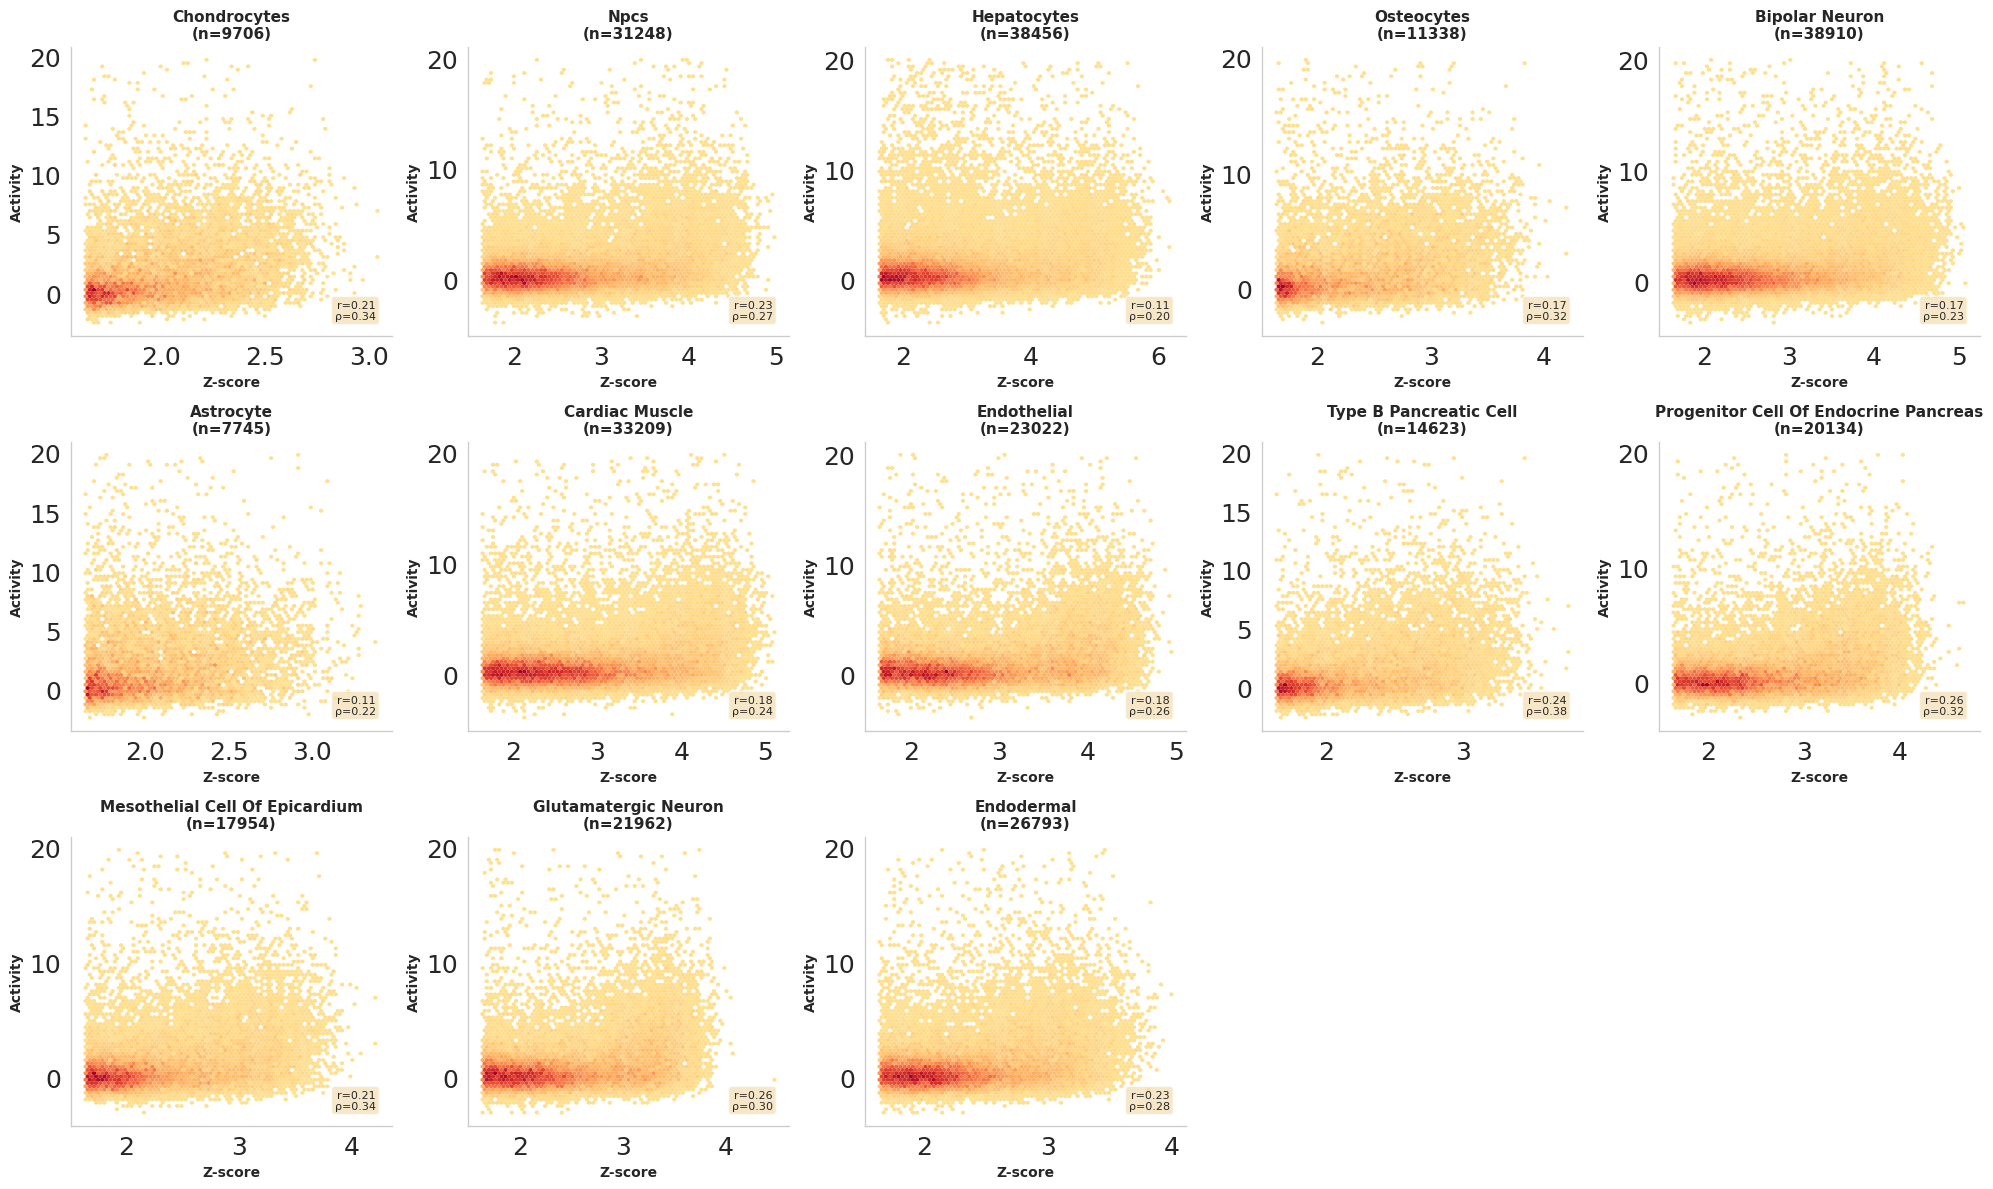


✓ Combined grid figure saved:
  PNG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/zscore_activity_correlation/all_cell_types_zscore_activity_grid_PLS_CA-H3K4me3_pELS_dELS.png
  SVG: /home/labs/davidgo/nadavmi/hMPRA/cell_type_specificity/zscore_activity_correlation/all_cell_types_zscore_activity_grid_PLS_CA-H3K4me3_pELS_dELS.svg


In [64]:
# Phase 5.4: Combined grid visualization - all cell types
keep_classes = ["PLS", "CA-H3K4me3", "pELS", "dELS"]

# Create a grid of hexbin plots for all cell types
n_cell_types = len(all_cell_types)
n_cols = 5
n_rows = int(np.ceil(n_cell_types / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

# Store z_score data for each cell type
all_data = {}

for idx, cell_type in enumerate(all_cell_types):
    ax = axes_flat[idx]
    
    # Process cell type
    result_df = process_cell_type_zscore_activity(
        cell_type=cell_type,
        z_score_file_dict=SCREEN_Z_score_per_celltype,
        screen_bed_file_dict=SCREEN_FILE_BY_CELLTYPE,
        oligos_bed_hg38=oligos_bed_hg38,
        oligos_df=oligos,
        keep_classes=keep_classes
    )
    
    # Ensure proper dtypes
    result_df["z_score"] = pd.to_numeric(result_df["z_score"], errors="coerce")
    result_df["normalized_activity_estimate_derived"] = pd.to_numeric(result_df["normalized_activity_estimate_derived"], errors="coerce")
    result_df_clean = result_df.dropna(subset=["normalized_activity_estimate_derived", "z_score"])
    
    # Store data
    all_data[cell_type] = result_df_clean
    
    # Filter for plotting
    plot_data = result_df_clean[result_df_clean['normalized_activity_estimate_derived'] < 20]
    
    if len(plot_data) > 2:
        # Create hexbin
        hexbin = ax.hexbin(
            plot_data["z_score"],
            plot_data["normalized_activity_estimate_derived"],
            gridsize=70,
            cmap=custom_cmap_bolder,
            mincnt=1,
            edgecolors="none"
        )
        
        # Compute correlations
        pearson_r, pearson_p = stats.pearsonr(result_df_clean["z_score"], result_df_clean["normalized_activity_estimate_derived"])
        spearman_r, spearman_p = stats.spearmanr(result_df_clean["z_score"], result_df_clean["normalized_activity_estimate_derived"])
        
        # Labels and title
        ax.set_xlabel("Z-score", fontsize=10, fontweight="bold")
        ax.set_ylabel("Activity", fontsize=10, fontweight="bold")
        ax.set_title(f"{cell_type.replace('_', ' ').title()}\n(n={len(result_df_clean)})", 
                     fontsize=11, fontweight="bold")
        ax.grid(False)
        
        # Add correlation text
        textstr = f"r={pearson_r:.2f}\nρ={spearman_r:.2f}"
        ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=8,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    else:
        ax.text(0.5, 0.5, f"Insufficient data\n(n={len(result_df_clean)})", 
                transform=ax.transAxes, ha='center', va='center', fontsize=10)
        ax.set_title(cell_type.replace('_', ' ').title(), fontsize=11, fontweight="bold")

# Hide empty subplots
for idx in range(n_cell_types, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()

# Save combined figure
grid_png_path = fig_dir / f"all_cell_types_zscore_activity_grid_{class_tag}.png"
grid_svg_path = fig_dir / f"all_cell_types_zscore_activity_grid_{class_tag}.svg"

fig.savefig(grid_png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(grid_svg_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"\n✓ Combined grid figure saved:")
print(f"  PNG: {grid_png_path}")
print(f"  SVG: {grid_svg_path}")


# Human-Gorilla hybrids - Number of Genes

In [12]:
hybrids_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/hybrids_TPM/ExpLBM_HG_polarization_results.tsv'
hybrids_df = pd.read_csv(hybrids_path, sep="\t")


In [ ]:
hybrids_df[]

,Gene,ExpLBM_TPM_human_allele_HG,ExpLBM_TPM_chimp_allele_HC,ExpLBM_TPM_gorilla_allele_HG,ExpLBM_log2TPM_human_allele_HG,ExpLBM_log2TPM_human_allele_HG.1,ExpLBM_log2TPM_human_allele_HG.2,ExpLBM_log2TPM_human_allele_HG.3,ExpLBM_log2TPM_chimp_allele_HC,ExpLBM_log2TPM_gorilla_allele_HG,HG_LFC_human_ref,HG_pvalue_human_ref,HG_padj_human_ref,derived,d_CH,d_CG
0,A1BG,0.851414,0.527905,1.412338,0.888627,0.888627,0.888627,0.888627,0.611555,1.270432,-0.741230,2.282205e-04,5.659326e-04,gorilla-derived,0.277073,0.658877
1,AACS,7.535759,4.364058,4.077082,3.093519,3.093519,3.093519,3.093519,2.423325,2.344000,0.840838,5.576118e-38,8.238477e-37,human-derived,0.670195,0.079325
2,AADAT,15.999825,23.513955,20.071359,4.087448,4.087448,4.087448,4.087448,4.615531,4.397211,-0.365185,1.485566e-06,4.672001e-06,human-derived,0.528083,0.218320
3,AAMDC,6.994841,3.799426,23.706576,2.999069,2.999069,2.999069,2.999069,2.262862,4.626823,-1.794649,1.847337e-62,5.232420e-61,gorilla-derived,0.736207,2.363961
4,AAR2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204526,4.172549e-05,1.128937e-04,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,ZWINT,85.502970,76.686176,27.709627,6.434678,6.434678,6.434678,6.434678,6.279586,4.843463,1.584320,2.022199e-234,5.180965e-232,gorilla-derived,0.155092,1.436123
7476,ZYG11A,0.278703,0.506932,0.511839,0.354681,0.354681,0.354681,0.354681,0.591614,0.596304,-0.793738,1.881984e-02,3.427400e-02,human-derived,0.236934,0.004690
7477,ZYG11B,10.545895,9.215758,18.107503,3.529308,3.529308,3.529308,3.529308,3.352724,4.256067,-0.819406,3.746446e-50,7.828302e-49,gorilla-derived,0.176584,0.903343
7478,ZYX,79.652370,48.106351,67.463777,6.333645,6.333645,6.333645,6.333645,5.617838,6.097269,0.196890,6.451497e-07,2.100440e-06,human-derived,0.715807,0.479431


In [14]:
hybrids_path_chimp = '/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/hybrids_TPM/ExpLBM_polarization_results.tsv'
hybrids_df_chimp = pd.read_csv(hybrids_path_chimp, sep="\t")

In [15]:
hybrids_df_chimp

,Gene,ExpLBM_TPM_human_allele,ExpLBM_TPM_human_allele_HG,ExpLBM_TPM_chimp_allele,ExpLBM_TPM_gorilla_allele,ExpLBM_TPM_total,ExpLBM_log2TPM_human_allele,ExpLBM_log2TPM_human_allele_HG,ExpLBM_log2TPM_chimp_allele,ExpLBM_log2TPM_gorilla_allele,...,ExpLBM_LFC_human_ref,ExpLBM_LFC_padj_human_ref,ExpLBM_LFC_chimp_ref,ExpLBM_LFC_padj_chimp_ref,ExpLBM_gene_ase_type,d_GH,d_GC,G_clipped,human_derived_score,derived
0,A1BG,0.589528,0.851414,0.527905,1.412338,2.210705,0.668598,0.888627,0.611555,1.270432,...,0.230332,0.394157,0.268019,0.307232,nonASE,0.601834,0.658877,0.589528,-1.000000,chimp-derived
1,A2M,1.409486,1.597975,1.120505,1.318553,4.860193,1.268725,1.377387,1.084408,1.213224,...,0.351554,0.011117,0.278937,0.053456,nonASE,0.055501,0.128817,1.318553,-0.370662,chimp-derived
2,A2MP1,0.011313,0.030674,0.016085,0.006907,0.036106,0.016230,0.043588,0.023021,0.009931,...,-0.124703,0.848341,0.205740,0.684719,else,0.006299,0.013090,0.011313,-1.000000,chimp-derived
3,NAT1,2.001059,2.470029,1.603822,1.688204,3.989507,1.585472,1.794948,1.380631,1.426642,...,0.341566,0.014630,0.434379,0.001459,ASE,0.158829,0.046012,1.688204,0.575156,human-derived
4,NAT2,0.573581,0.901408,0.655862,0.828586,1.762164,0.654052,0.927068,0.727582,0.870728,...,-0.157079,0.687675,0.080235,0.856452,else,0.216677,0.143146,0.655862,1.000000,human-derived
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92614,bP-2189O9.5,0.010645,0.000000,0.008531,0.000000,0.045655,0.015276,0.000000,0.012255,0.000000,...,-0.005127,NaN,NaN,NaN,else,0.015276,0.012255,0.008531,1.000000,human-derived
92615,hsa-mir-1253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN
92616,hsa-mir-423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN
92617,snoZ196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,else,0.000000,0.000000,0.000000,NaN,NaN
